<a href="https://colab.research.google.com/github/ShlokGadhave/-User-Experience-through-Collaborative-Filtering-and-Big-Data-Analytics-Netflix-/blob/main/Netflix_Reommendaion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pyspark

In [ ]:
# ==========================================
# STEP 1: Install PySpark
# ==========================================
!pip install pyspark

# ==========================================
# STEP 2: Import Libraries
# ==========================================
import pandas as pd
import numpy as np
from pyspark.sql import SparkSession
from pyspark.ml.recommendation import ALS

# ==========================================
# STEP 3: Generate Big Dataset
# ==========================================
NUM_USERS = 1000
NUM_MOVIES = 500
NUM_RECORDS = 100000

np.random.seed(42)

users = np.random.randint(1, NUM_USERS + 1, NUM_RECORDS)
movies = np.random.randint(1, NUM_MOVIES + 1, NUM_RECORDS)
ratings = np.random.randint(1, 6, NUM_RECORDS)

df = pd.DataFrame({
    "user": users,
    "movie": movies,
    "rating": ratings
})

df = df.drop_duplicates()

df.to_csv("netflix_big_data.csv", index=False)

print("✅ Dataset Created")
print("Total Records:", len(df))
df.head()

# ==========================================
# STEP 4: Start Spark Session
# ==========================================
spark = SparkSession.builder \
    .appName("Netflix_BigData_Recommendation") \
    .getOrCreate()

# ==========================================
# STEP 5: Load Dataset into Spark
# ==========================================
spark_df = spark.read.csv("netflix_big_data.csv",
                          header=True,
                          inferSchema=True)

print("=== Dataset Preview ===")
spark_df.show(5)

# ==========================================
# STEP 6: Build ALS Model
# ==========================================
als = ALS(
    userCol="user",
    itemCol="movie",
    ratingCol="rating",
    coldStartStrategy="drop",
    nonnegative=True,
    maxIter=10,
    regParam=0.1
)

model = als.fit(spark_df)

# ==========================================
# STEP 7: Generate Recommendations
# ==========================================
print("=== Top 3 Recommendations per User ===")

recommendations = model.recommendForAllUsers(3)
recommendations.show(truncate=False)

# ==========================================
# STEP 8: Stop Spark Session
# ==========================================
spark.stop()

✅ Dataset Created
Total Records: 98024
=== Dataset Preview ===
+----+-----+------+
|user|movie|rating|
+----+-----+------+
| 103|  202|     4|
| 436|  384|     3|
| 861|  428|     1|
| 271|  158|     1|
| 107|  233|     5|
+----+-----+------+
only showing top 5 rows
=== Top 3 Recommendations per User ===
+----+------------------------------------------------------+
|user|recommendations                                       |
+----+------------------------------------------------------+
|1   |[{278, 3.713592}, {368, 3.6667266}, {282, 3.664454}]  |
|2   |[{227, 3.6757412}, {144, 3.56145}, {180, 3.5396767}]  |
|3   |[{330, 3.6188838}, {475, 3.6119814}, {45, 3.5596628}] |
|4   |[{258, 3.4549553}, {257, 3.4186058}, {131, 3.3997724}]|
|5   |[{349, 3.744048}, {439, 3.6754296}, {399, 3.6318083}] |
|6   |[{476, 4.139084}, {349, 4.106768}, {111, 4.0555077}]  |
|7   |[{251, 3.5465407}, {349, 3.5018425}, {58, 3.499379}]  |
|8   |[{14, 3.5172951}, {256, 3.501544}, {180, 3.493125}]   |
|9   |[{183,

✅ Dataset Created Successfully!
Total Records: 98024
   user  movie  rating
0   103    202       4
1   436    384       3
2   861    428       1
3   271    158       1
4   107    233       5
=== Dataset Preview ===
+----+-----+------+
|user|movie|rating|
+----+-----+------+
| 103|  202|     4|
| 436|  384|     3|
| 861|  428|     1|
| 271|  158|     1|
| 107|  233|     5|
+----+-----+------+
only showing top 5 rows
=== Raw Recommendations ===
+----+------------------------------------------------------+
|user|recommendations                                       |
+----+------------------------------------------------------+
|1   |[{278, 3.713592}, {368, 3.6667266}, {282, 3.664454}]  |
|2   |[{227, 3.6757412}, {144, 3.56145}, {180, 3.5396767}]  |
|3   |[{330, 3.6188838}, {475, 3.6119814}, {45, 3.5596628}] |
|4   |[{258, 3.4549553}, {257, 3.4186058}, {131, 3.3997724}]|
|5   |[{349, 3.744048}, {439, 3.6754296}, {399, 3.6318083}] |
+----+---------------------------------------------------

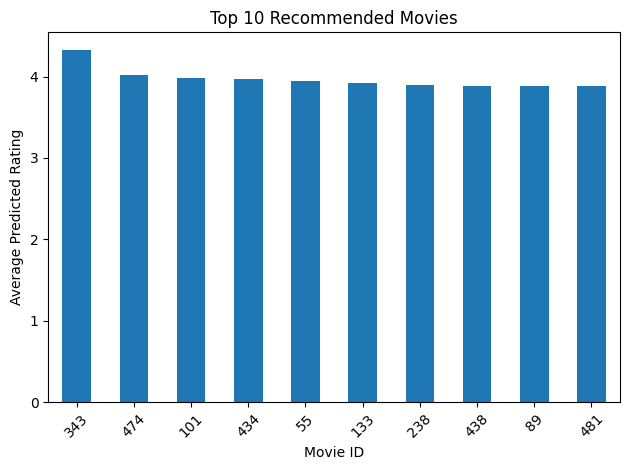

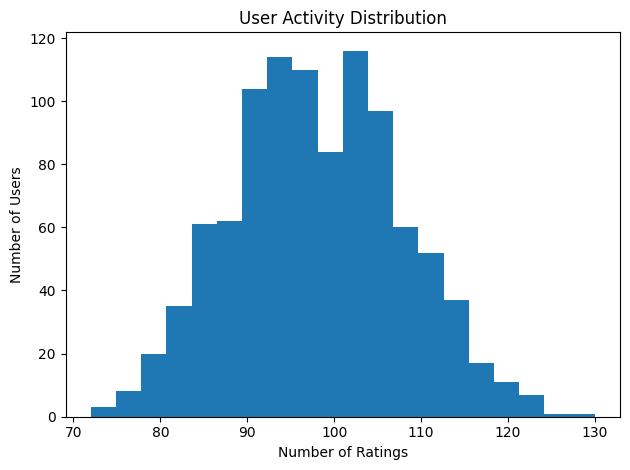

=== Most Popular Movies ===
     movie  count
199    189    246
54     236    241
347    143    235
258     23    232
312    267    230
310    404    229
250      4    229
475    174    226
75     230    226
409     58    226


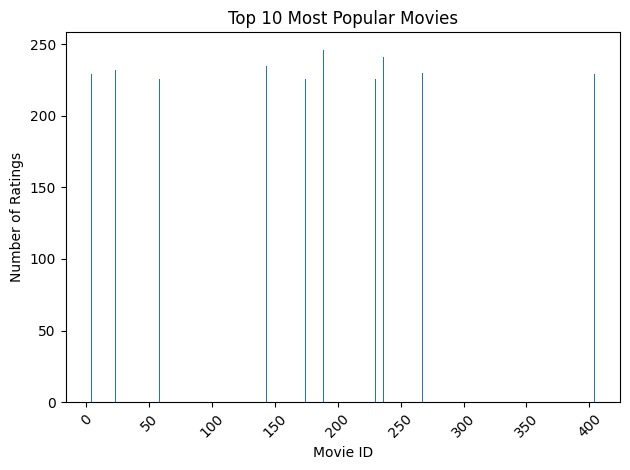

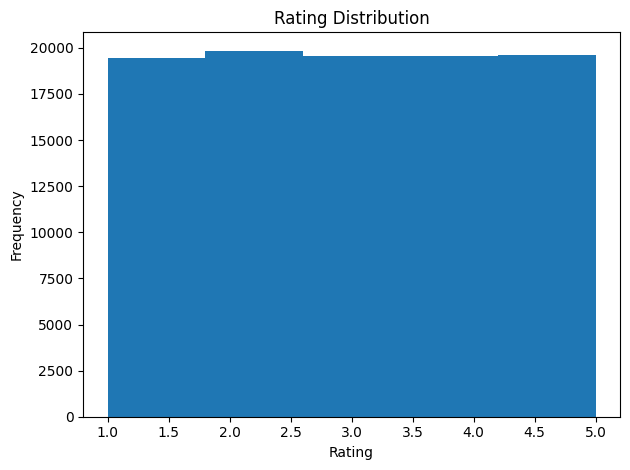

In [ ]:
# ==========================================
# STEP 1: Install PySpark
# ==========================================
!pip install pyspark

# ==========================================
# STEP 2: Import Libraries
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.ml.recommendation import ALS

# ==========================================
# STEP 3: Generate Big Dataset
# ==========================================
NUM_USERS = 1000
NUM_MOVIES = 500
NUM_RECORDS = 100000

np.random.seed(42)

users = np.random.randint(1, NUM_USERS + 1, NUM_RECORDS)
movies = np.random.randint(1, NUM_MOVIES + 1, NUM_RECORDS)
ratings = np.random.randint(1, 6, NUM_RECORDS)

df = pd.DataFrame({
    "user": users,
    "movie": movies,
    "rating": ratings
})

df = df.drop_duplicates()
df.to_csv("netflix_big_data.csv", index=False)

print("✅ Dataset Created Successfully!")
print("Total Records:", len(df))
print(df.head())

# ==========================================
# STEP 4: Start Spark Session
# ==========================================
spark = SparkSession.builder \
    .appName("Netflix_BigData_Recommendation") \
    .getOrCreate()

# ==========================================
# STEP 5: Load Dataset into Spark
# ==========================================
spark_df = spark.read.csv("netflix_big_data.csv",
                          header=True,
                          inferSchema=True)

print("=== Dataset Preview ===")
spark_df.show(5)

# ==========================================
# STEP 6: Build ALS Model
# ==========================================
als = ALS(
    userCol="user",
    itemCol="movie",
    ratingCol="rating",
    coldStartStrategy="drop",
    nonnegative=True,
    maxIter=10,
    regParam=0.1
)

model = als.fit(spark_df)

# ==========================================
# STEP 7: Generate Recommendations
# ==========================================
recommendations = model.recommendForAllUsers(3)
print("=== Raw Recommendations ===")
recommendations.show(5, truncate=False)

# ==========================================
# STEP 8: Convert to Pandas (for Analysis)
# ==========================================
rec_df = recommendations.toPandas()

rec_expanded = rec_df.explode("recommendations")
rec_expanded["movie"] = rec_expanded["recommendations"].apply(lambda x: x[0])
rec_expanded["predicted_rating"] = rec_expanded["recommendations"].apply(lambda x: float(x[1]))
rec_expanded = rec_expanded.drop("recommendations", axis=1)

print("=== Final Recommendation Table ===")
print(rec_expanded.head(10))

# ==========================================
# STEP 9: Top Recommended Movies
# ==========================================
top_movies = rec_expanded.groupby("movie")["predicted_rating"].mean().sort_values(ascending=False).head(10)

print("=== Top 10 Recommended Movies ===")
print(top_movies)

# ==========================================
# STEP 10: Plot - Top Recommended Movies
# ==========================================
plt.figure()
top_movies.plot(kind='bar')
plt.title("Top 10 Recommended Movies")
plt.xlabel("Movie ID")
plt.ylabel("Average Predicted Rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ==========================================
# STEP 11: User Activity Analysis
# ==========================================
user_activity = spark_df.groupBy("user").count().toPandas()

plt.figure()
plt.hist(user_activity["count"], bins=20)
plt.title("User Activity Distribution")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.show()

# ==========================================
# STEP 12: Movie Popularity Analysis
# ==========================================
movie_popularity = spark_df.groupBy("movie").count().toPandas()
top_popular_movies = movie_popularity.sort_values(by="count", ascending=False).head(10)

print("=== Most Popular Movies ===")
print(top_popular_movies)

# ==========================================
# STEP 13: Plot - Movie Popularity
# ==========================================
plt.figure()
plt.bar(top_popular_movies["movie"], top_popular_movies["count"])
plt.title("Top 10 Most Popular Movies")
plt.xlabel("Movie ID")
plt.ylabel("Number of Ratings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ==========================================
# STEP 14: Rating Distribution
# ==========================================
ratings_df = spark_df.select("rating").toPandas()

plt.figure()
plt.hist(ratings_df["rating"], bins=5)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# ==========================================
# STEP 15: Stop Spark
# ==========================================
spark.stop()

✅ Dataset Created Successfully!
Total Records: 98024
   user  movie  rating
0   103    202       4
1   436    384       3
2   861    428       1
3   271    158       1
4   107    233       5
=== Dataset Preview ===
+----+-----+------+
|user|movie|rating|
+----+-----+------+
| 103|  202|     4|
| 436|  384|     3|
| 861|  428|     1|
| 271|  158|     1|
| 107|  233|     5|
+----+-----+------+
only showing top 5 rows
=== Raw Recommendations ===
+----+------------------------------------------------------+
|user|recommendations                                       |
+----+------------------------------------------------------+
|1   |[{278, 3.713592}, {368, 3.6667266}, {282, 3.664454}]  |
|2   |[{227, 3.6757412}, {144, 3.56145}, {180, 3.5396767}]  |
|3   |[{330, 3.6188838}, {475, 3.6119814}, {45, 3.5596628}] |
|4   |[{258, 3.4549553}, {257, 3.4186058}, {131, 3.3997724}]|
|5   |[{349, 3.744048}, {439, 3.6754296}, {399, 3.6318083}] |
+----+---------------------------------------------------

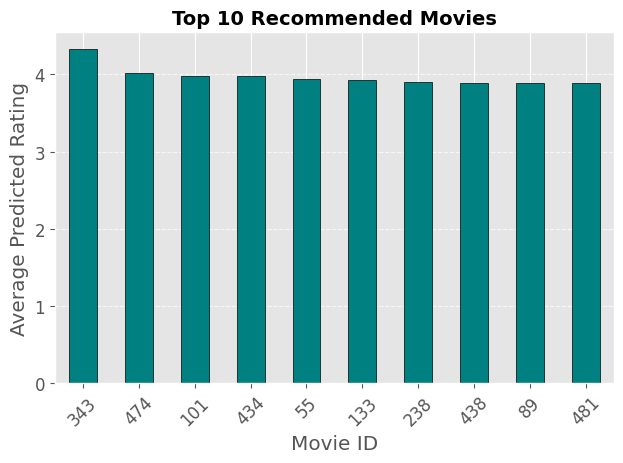

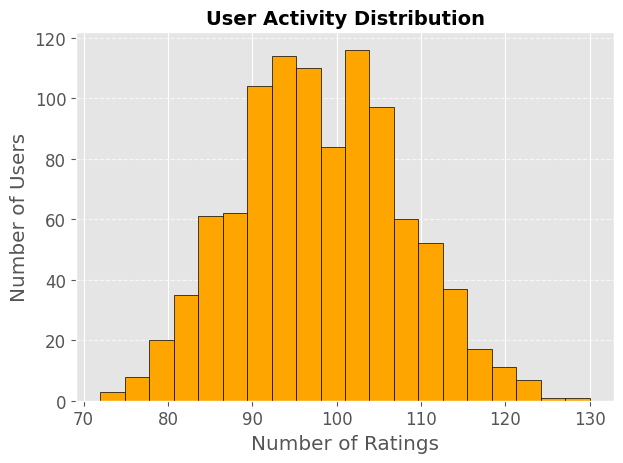

=== Most Popular Movies ===
     movie  count
199    189    246
54     236    241
347    143    235
258     23    232
312    267    230
310    404    229
250      4    229
475    174    226
75     230    226
409     58    226


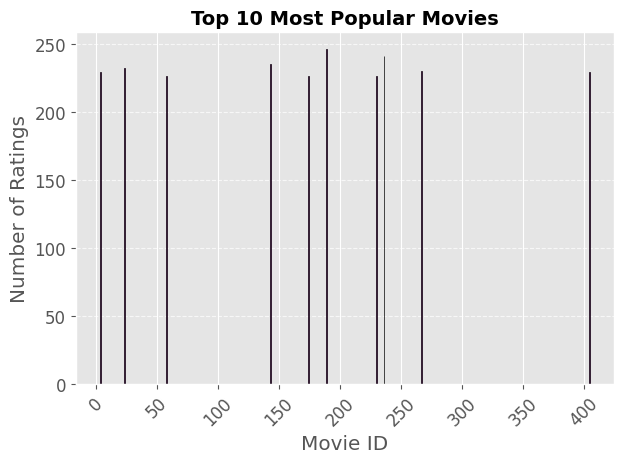

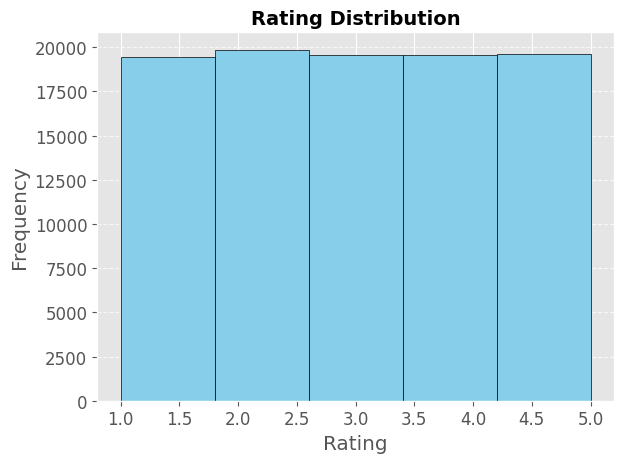

In [ ]:
# ==========================================
# STEP 1: Install PySpark
# ==========================================
!pip install pyspark

# ==========================================
# STEP 2: Import Libraries
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.ml.recommendation import ALS

# Professional styling
plt.style.use('ggplot')
plt.rcParams.update({'font.size': 12})

# ==========================================
# STEP 3: Generate Big Dataset
# ==========================================
NUM_USERS = 1000
NUM_MOVIES = 500
NUM_RECORDS = 100000

np.random.seed(42)

users = np.random.randint(1, NUM_USERS + 1, NUM_RECORDS)
movies = np.random.randint(1, NUM_MOVIES + 1, NUM_RECORDS)
ratings = np.random.randint(1, 6, NUM_RECORDS)

df = pd.DataFrame({
    "user": users,
    "movie": movies,
    "rating": ratings
})

df = df.drop_duplicates()
df.to_csv("netflix_big_data.csv", index=False)

print("✅ Dataset Created Successfully!")
print("Total Records:", len(df))
print(df.head())

# ==========================================
# STEP 4: Start Spark Session
# ==========================================
spark = SparkSession.builder \
    .appName("Netflix_BigData_Recommendation") \
    .getOrCreate()

# ==========================================
# STEP 5: Load Dataset into Spark
# ==========================================
spark_df = spark.read.csv("netflix_big_data.csv",
                          header=True,
                          inferSchema=True)

print("=== Dataset Preview ===")
spark_df.show(5)

# ==========================================
# STEP 6: Build ALS Model
# ==========================================
als = ALS(
    userCol="user",
    itemCol="movie",
    ratingCol="rating",
    coldStartStrategy="drop",
    nonnegative=True,
    maxIter=10,
    regParam=0.1
)

model = als.fit(spark_df)

# ==========================================
# STEP 7: Generate Recommendations
# ==========================================
recommendations = model.recommendForAllUsers(3)

print("=== Raw Recommendations ===")
recommendations.show(5, truncate=False)

# ==========================================
# STEP 8: Convert to Pandas (Clean Table)
# ==========================================
rec_df = recommendations.toPandas()

rec_expanded = rec_df.explode("recommendations")
rec_expanded["movie"] = rec_expanded["recommendations"].apply(lambda x: x[0])
rec_expanded["predicted_rating"] = rec_expanded["recommendations"].apply(lambda x: float(x[1]))
rec_expanded = rec_expanded.drop("recommendations", axis=1)

print("=== Final Recommendation Table ===")
print(rec_expanded.head(10))

# ==========================================
# STEP 9: Top Recommended Movies
# ==========================================
top_movies = rec_expanded.groupby("movie")["predicted_rating"].mean().sort_values(ascending=False).head(10)

print("=== Top 10 Recommended Movies ===")
print(top_movies)

# ==========================================
# STEP 10: Plot - Top Recommended Movies
# ==========================================
plt.figure()
top_movies.plot(kind='bar', color='teal', edgecolor='black')
plt.title("Top 10 Recommended Movies", fontsize=14, fontweight='bold')
plt.xlabel("Movie ID")
plt.ylabel("Average Predicted Rating")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# ==========================================
# STEP 11: User Activity Analysis
# ==========================================
user_activity = spark_df.groupBy("user").count().toPandas()

plt.figure()
plt.hist(user_activity["count"], bins=20, color='orange', edgecolor='black')
plt.title("User Activity Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# ==========================================
# STEP 12: Movie Popularity Analysis
# ==========================================
movie_popularity = spark_df.groupBy("movie").count().toPandas()
top_popular_movies = movie_popularity.sort_values(by="count", ascending=False).head(10)

print("=== Most Popular Movies ===")
print(top_popular_movies)

# ==========================================
# STEP 13: Plot - Movie Popularity
# ==========================================
plt.figure()
plt.bar(top_popular_movies["movie"], top_popular_movies["count"],
        color='purple', edgecolor='black')
plt.title("Top 10 Most Popular Movies", fontsize=14, fontweight='bold')
plt.xlabel("Movie ID")
plt.ylabel("Number of Ratings")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# ==========================================
# STEP 14: Rating Distribution
# ==========================================
ratings_df = spark_df.select("rating").toPandas()

plt.figure()
plt.hist(ratings_df["rating"], bins=5, color='skyblue', edgecolor='black')
plt.title("Rating Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# ==========================================
# STEP 15: Stop Spark
# ==========================================
spark.stop()

In [ ]:
!pip install seaborn

✅ Dataset Created Successfully!
Total Records: 98024
   user  movie  rating
0   103    202       4
1   436    384       3
2   861    428       1
3   271    158       1
4   107    233       5
=== Dataset Preview ===
+----+-----+------+
|user|movie|rating|
+----+-----+------+
| 103|  202|     4|
| 436|  384|     3|
| 861|  428|     1|
| 271|  158|     1|
| 107|  233|     5|
+----+-----+------+
only showing top 5 rows
=== Raw Recommendations ===
+----+------------------------------------------------------+
|user|recommendations                                       |
+----+------------------------------------------------------+
|1   |[{278, 3.713592}, {368, 3.6667266}, {282, 3.664454}]  |
|2   |[{227, 3.6757412}, {144, 3.56145}, {180, 3.5396767}]  |
|3   |[{330, 3.6188838}, {475, 3.6119814}, {45, 3.5596628}] |
|4   |[{258, 3.4549553}, {257, 3.4186058}, {131, 3.3997724}]|
|5   |[{349, 3.744048}, {439, 3.6754296}, {399, 3.6318083}] |
+----+---------------------------------------------------

/tmp/ipykernel_2470/1749422605.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_movies.index, y=top_movies.values, palette="viridis")


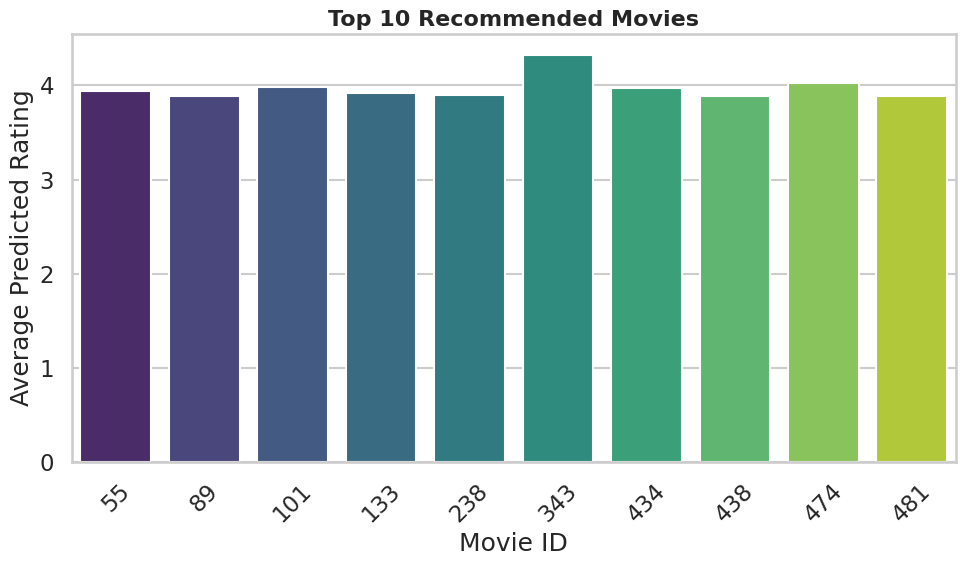

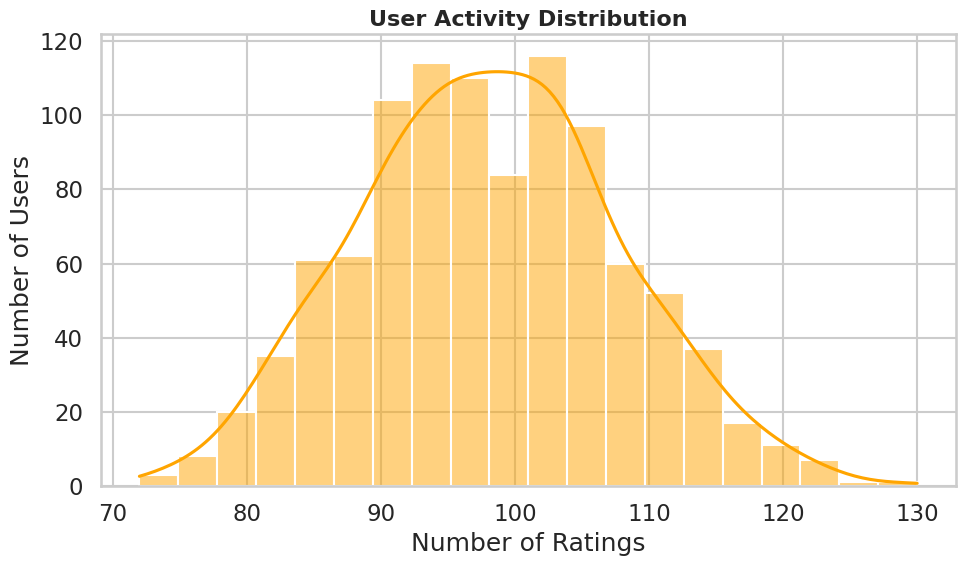

=== Most Popular Movies ===
     movie  count
199    189    246
54     236    241
347    143    235
258     23    232
312    267    230
310    404    229
250      4    229
475    174    226
75     230    226
409     58    226


/tmp/ipykernel_2470/1749422605.py:149: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_popular_movies["movie"],


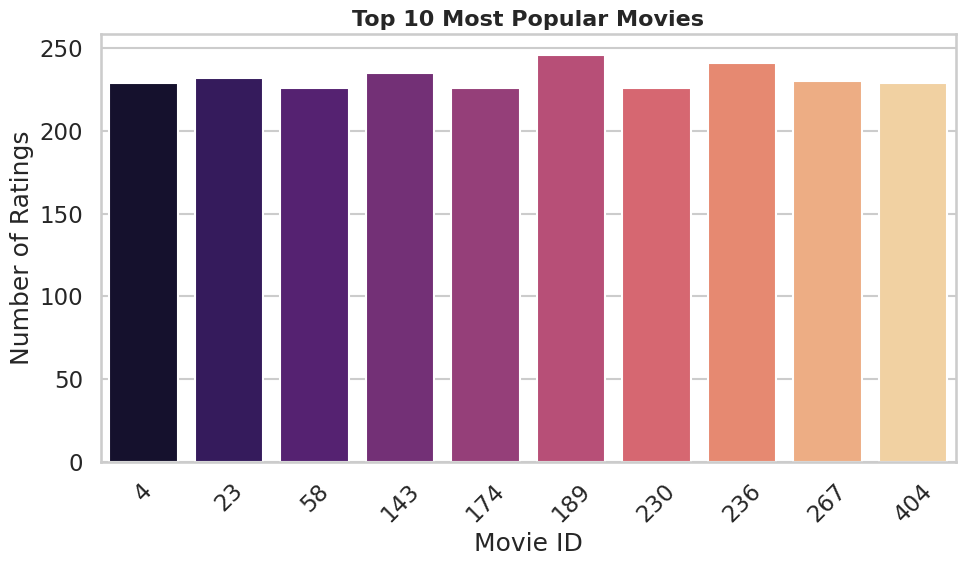

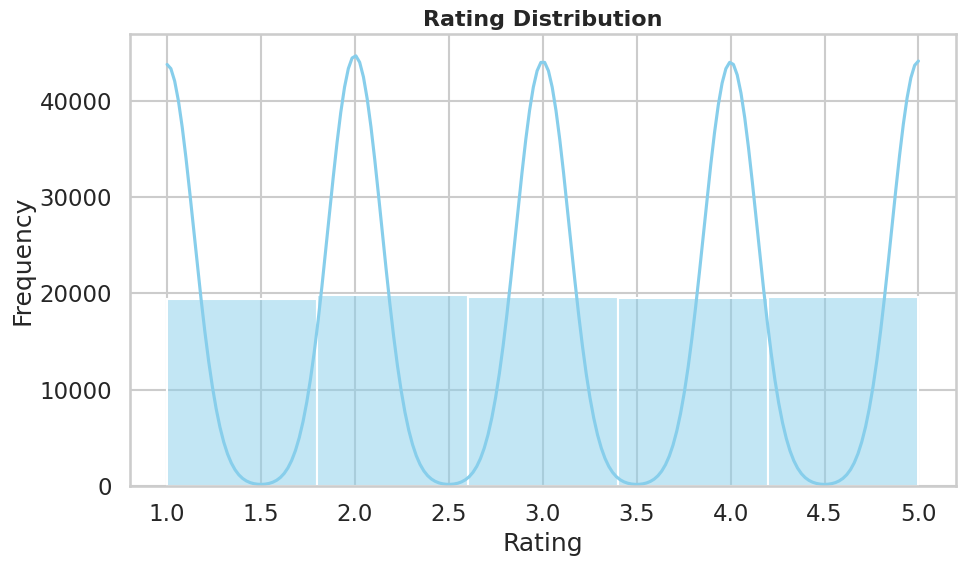

In [ ]:
# ==========================================
# STEP 1: Install Libraries
# ==========================================
!pip install pyspark seaborn

# ==========================================
# STEP 2: Import Libraries
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.ml.recommendation import ALS

# Seaborn styling (professional look)
sns.set_style("whitegrid")
sns.set_context("talk")

# ==========================================
# STEP 3: Generate Big Dataset
# ==========================================
NUM_USERS = 1000
NUM_MOVIES = 500
NUM_RECORDS = 100000

np.random.seed(42)

users = np.random.randint(1, NUM_USERS + 1, NUM_RECORDS)
movies = np.random.randint(1, NUM_MOVIES + 1, NUM_RECORDS)
ratings = np.random.randint(1, 6, NUM_RECORDS)

df = pd.DataFrame({
    "user": users,
    "movie": movies,
    "rating": ratings
})

df = df.drop_duplicates()
df.to_csv("netflix_big_data.csv", index=False)

print("✅ Dataset Created Successfully!")
print("Total Records:", len(df))
print(df.head())

# ==========================================
# STEP 4: Start Spark Session
# ==========================================
spark = SparkSession.builder \
    .appName("Netflix_BigData_Recommendation") \
    .getOrCreate()

# ==========================================
# STEP 5: Load Dataset into Spark
# ==========================================
spark_df = spark.read.csv("netflix_big_data.csv",
                          header=True,
                          inferSchema=True)

print("=== Dataset Preview ===")
spark_df.show(5)

# ==========================================
# STEP 6: Build ALS Model
# ==========================================
als = ALS(
    userCol="user",
    itemCol="movie",
    ratingCol="rating",
    coldStartStrategy="drop",
    nonnegative=True,
    maxIter=10,
    regParam=0.1
)

model = als.fit(spark_df)

# ==========================================
# STEP 7: Generate Recommendations
# ==========================================
recommendations = model.recommendForAllUsers(3)

print("=== Raw Recommendations ===")
recommendations.show(5, truncate=False)

# ==========================================
# STEP 8: Convert to Pandas (Clean Table)
# ==========================================
rec_df = recommendations.toPandas()

rec_expanded = rec_df.explode("recommendations")
rec_expanded["movie"] = rec_expanded["recommendations"].apply(lambda x: x[0])
rec_expanded["predicted_rating"] = rec_expanded["recommendations"].apply(lambda x: float(x[1]))
rec_expanded = rec_expanded.drop("recommendations", axis=1)

print("=== Final Recommendation Table ===")
print(rec_expanded.head(10))

# ==========================================
# STEP 9: Top Recommended Movies
# ==========================================
top_movies = rec_expanded.groupby("movie")["predicted_rating"].mean() \
                        .sort_values(ascending=False).head(10)

print("=== Top 10 Recommended Movies ===")
print(top_movies)

# ==========================================
# STEP 10: Plot - Top Recommended Movies
# ==========================================
plt.figure(figsize=(10,6))
sns.barplot(x=top_movies.index, y=top_movies.values, palette="viridis")

plt.title("Top 10 Recommended Movies", fontsize=16, fontweight='bold')
plt.xlabel("Movie ID")
plt.ylabel("Average Predicted Rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ==========================================
# STEP 11: User Activity Analysis
# ==========================================
user_activity = spark_df.groupBy("user").count().toPandas()

plt.figure(figsize=(10,6))
sns.histplot(user_activity["count"], bins=20, kde=True, color="orange")

plt.title("User Activity Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.show()

# ==========================================
# STEP 12: Movie Popularity Analysis
# ==========================================
movie_popularity = spark_df.groupBy("movie").count().toPandas()
top_popular_movies = movie_popularity.sort_values(by="count", ascending=False).head(10)

print("=== Most Popular Movies ===")
print(top_popular_movies)

# ==========================================
# STEP 13: Plot - Movie Popularity
# ==========================================
plt.figure(figsize=(10,6))
sns.barplot(x=top_popular_movies["movie"],
            y=top_popular_movies["count"],
            palette="magma")

plt.title("Top 10 Most Popular Movies", fontsize=16, fontweight='bold')
plt.xlabel("Movie ID")
plt.ylabel("Number of Ratings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ==========================================
# STEP 14: Rating Distribution
# ==========================================
ratings_df = spark_df.select("rating").toPandas()

plt.figure(figsize=(10,6))
sns.histplot(ratings_df["rating"], bins=5, kde=True, color="skyblue")

plt.title("Rating Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# ==========================================
# STEP 15: Stop Spark
# ==========================================
spark.stop()